### EDA datos preprocesados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
jsonl_path = 
with open(jsonl_path, 'r', encoding='utf-8') as f:
    for line_num, line in enumerate(f, 1):
        try:
            data = json.loads(line.strip())
            if 'created_at' in data:
                data['created_at'] = pd.to_datetime(data['created_at'])
            records.append(data)
        except Exception as e:
            errors += 1
            if errors <= 5:  # Mostrar solo primeros 5 errores
                print(f"⚠️  Error en línea {line_num}: {e}")
            continue

if errors > 0:
    print(f"⚠️  Total de errores al cargar: {errors}")

df = pd.DataFrame(records)
print(f"✅ Cargados {len(df)} registros")
return df

📂 Cargando datos...
✅ Cargados 122,301 registros

📊 Forma del DataFrame: (122301, 24)

📋 Columnas disponibles:
['id', 'source', 'source_id', 'text', 'created_at', 'title', 'author', 'url', 'subreddit', 'medium', 'score', 'num_comments', 'sentiment_label', 'tags', 'cleaned_text', 'text_length', 'keyword_count', 'lang', 'metadata', 'predicted_sentiment', 'sentiment_confidence', 'sentiment_probs', 'sentiment_model', 'sentiment_analyzed_at']

INFORMACIÓN GENERAL

📅 Rango de fechas:
   Desde: 2020-01-18 15:21:17
   Hasta: 2025-11-18 00:07:57
   Total de días: 2131

📊 Por fuente:
source
reddit    122301
Name: count, dtype: int64

📊 Por subreddit (top 10):
subreddit
argentina    75027
merval       47274
Name: count, dtype: int64

ANÁLISIS DE SENTIMIENTO

📊 Distribución de sentimientos:
   POS: 11,626 (9.51%)
   NEG: 52,318 (42.78%)
   NEU: 58,357 (47.72%)


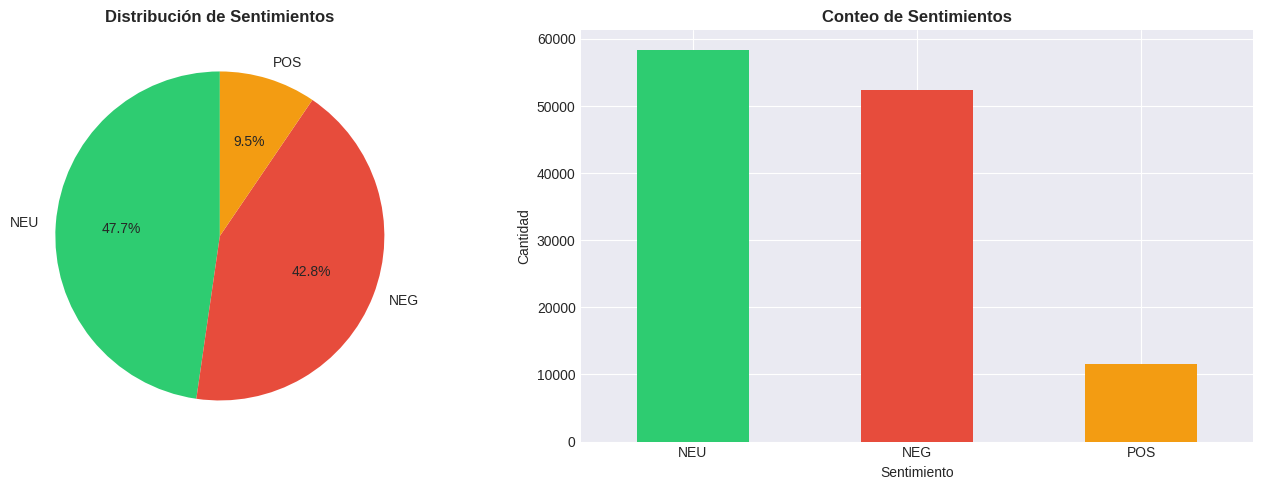


📊 Estadísticas de confianza:
   Media: 0.738
   Mediana: 0.746
   Mínimo: 0.340
   Máximo: 0.990
   Desviación estándar: 0.150


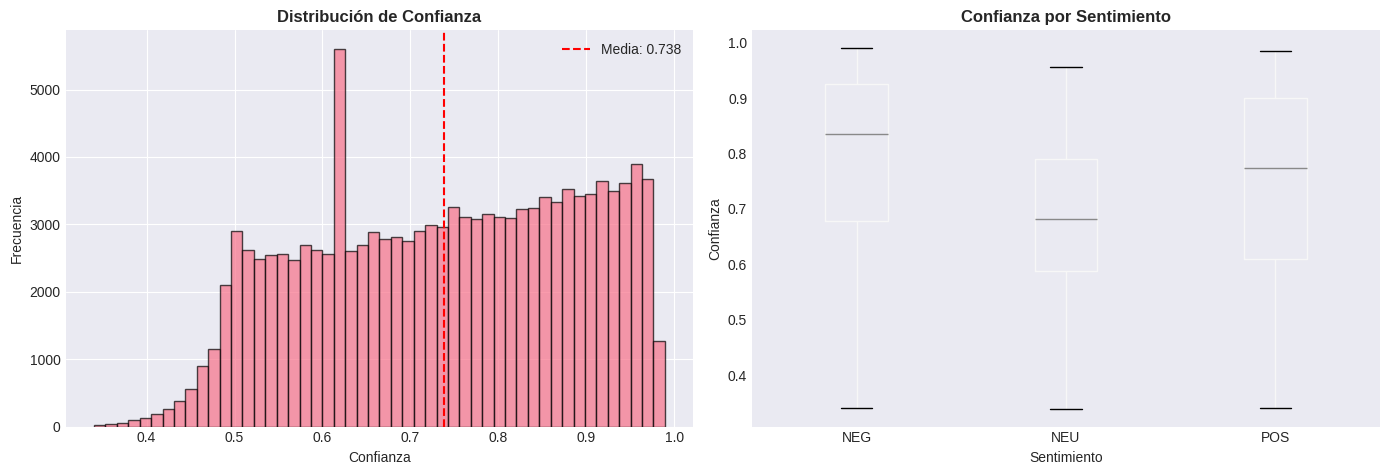


ANÁLISIS TEMPORAL

📊 Estadísticas diarias:
   Promedio de registros por día: 73.2
   Mediana de registros por día: 35.0
   Mínimo: 1
   Máximo: 1366
   Desviación estándar: 106.0


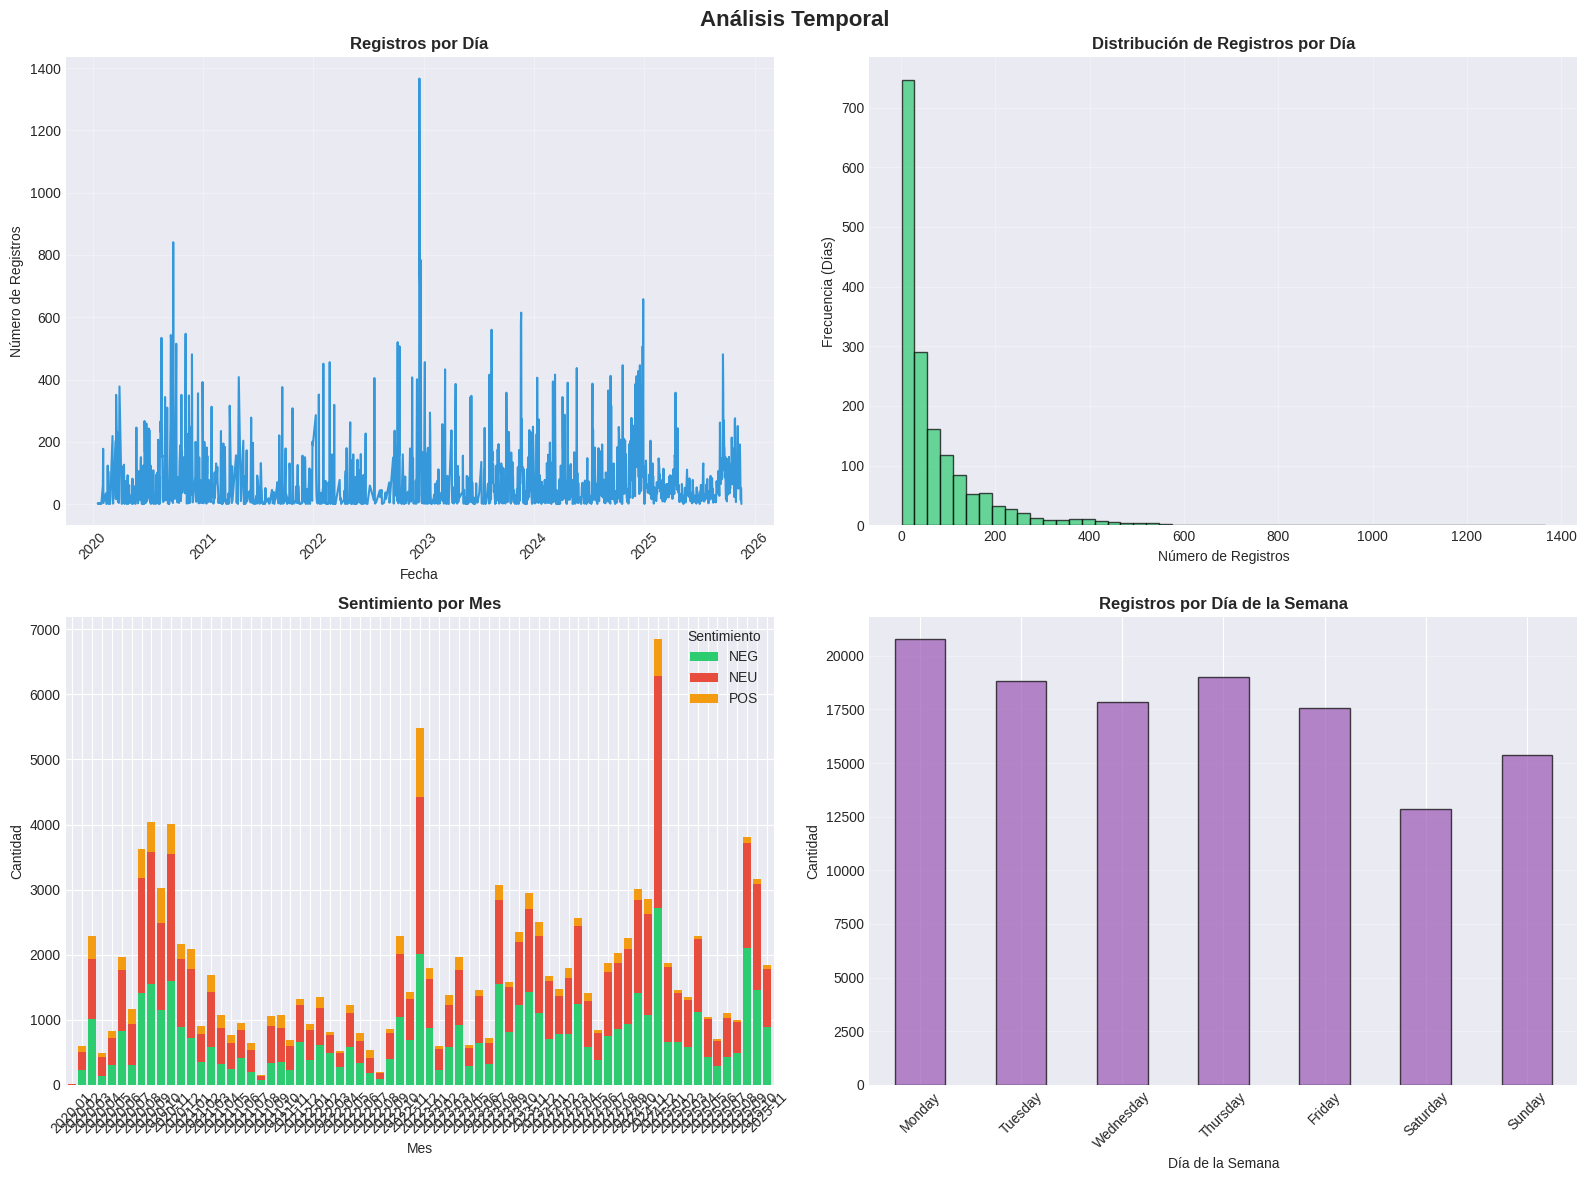


ANÁLISIS POR FUENTE

📊 Sentimiento por fuente:
predicted_sentiment    NEG    NEU    POS     All
source                                          
reddit               52318  58357  11626  122301
All                  52318  58357  11626  122301


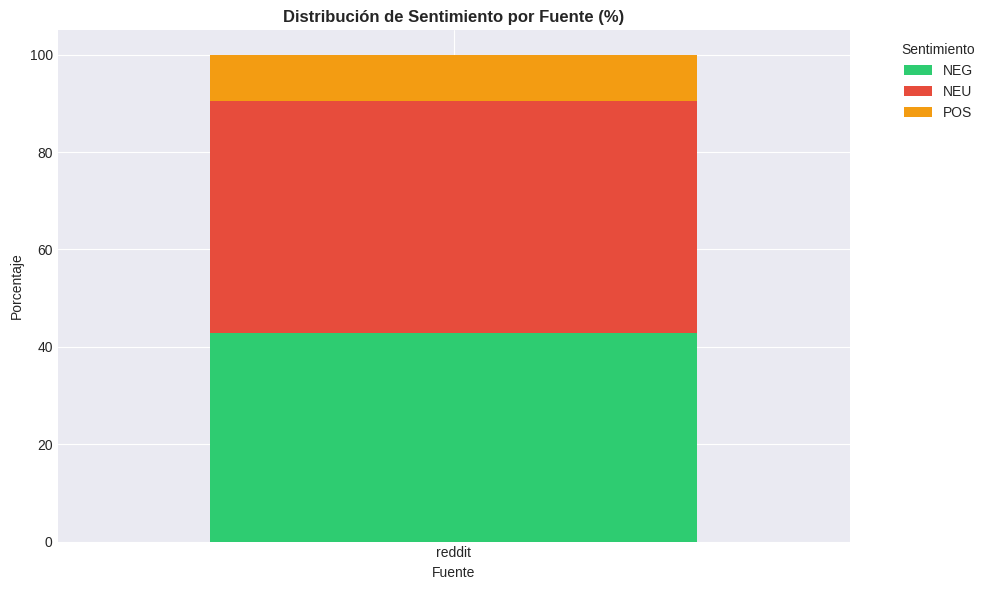


CALIDAD DE DATOS

📊 Valores nulos por columna:
                  Nulos  Porcentaje
title            122301  100.000000
url              122301  100.000000
medium           122301  100.000000
num_comments     122301  100.000000
sentiment_label  122301  100.000000
tags             122301  100.000000
keyword_count    122301  100.000000
lang               7311    5.977874

📊 Estadísticas de texto:
   Longitud promedio: 200.9 caracteres
   Longitud mediana: 97.0 caracteres
   Mínimo: 1 caracteres
   Máximo: 35822 caracteres

RESUMEN FINAL

✅ Total de registros: 122,301
✅ Rango de fechas: 2020-01-18 a 2025-11-18
✅ Cobertura de sentimiento: 100.00%
✅ Días únicos con datos: 1671
✅ Promedio de registros por día: 73.2

✅ EDA COMPLETADO


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# ============================================================================
# 1. CARGAR DATOS
# ============================================================================

jsonl_path = '/home/sebastian-mesch-henriques/Escritorio/MIA/deep_learning/stock_price_prediction_MIA/data/procesada/data-reddit-2025-2025-con-sentiment.jsonl'

print("📂 Cargando datos...")
records = []
with open(jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            data = json.loads(line.strip())
            if 'created_at' in data:
                data['created_at'] = pd.to_datetime(data['created_at'])
            records.append(data)
        except Exception as e:
            print(f"⚠️  Error al procesar línea: {e}")
            continue

df = pd.DataFrame(records)
print(f"✅ Cargados {len(df):,} registros")
print(f"\n📊 Forma del DataFrame: {df.shape}")
print(f"\n📋 Columnas disponibles:")
print(df.columns.tolist())

# ============================================================================
# 2. INFORMACIÓN GENERAL
# ============================================================================

print("\n" + "="*60)
print("INFORMACIÓN GENERAL")
print("="*60)

print(f"\n📅 Rango de fechas:")
print(f"   Desde: {df['created_at'].min()}")
print(f"   Hasta: {df['created_at'].max()}")
print(f"   Total de días: {(df['created_at'].max() - df['created_at'].min()).days + 1}")

print(f"\n📊 Por fuente:")
if 'source' in df.columns:
    print(df['source'].value_counts())

print(f"\n📊 Por subreddit (top 10):")
if 'subreddit' in df.columns:
    print(df['subreddit'].value_counts().head(10))

# ============================================================================
# 3. ANÁLISIS DE SENTIMIENTO
# ============================================================================

print("\n" + "="*60)
print("ANÁLISIS DE SENTIMIENTO")
print("="*60)

if 'predicted_sentiment' in df.columns:
    # Distribución de sentimientos
    sentiment_counts = df['predicted_sentiment'].value_counts()
    sentiment_pct = df['predicted_sentiment'].value_counts(normalize=True) * 100
    
    print(f"\n📊 Distribución de sentimientos:")
    for sentiment in ['POS', 'NEG', 'NEU']:
        count = sentiment_counts.get(sentiment, 0)
        pct = sentiment_pct.get(sentiment, 0)
        print(f"   {sentiment}: {count:,} ({pct:.2f}%)")
    
    # Sentimientos nulos
    null_sentiment = df['predicted_sentiment'].isna().sum()
    if null_sentiment > 0:
        print(f"\n⚠️  Registros sin sentimiento: {null_sentiment:,} ({null_sentiment/len(df)*100:.2f}%)")
    
    # Gráfico de distribución
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Pie chart
    sentiment_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', 
                         colors=['#2ecc71', '#e74c3c', '#f39c12'],
                         startangle=90)
    axes[0].set_title('Distribución de Sentimientos', fontweight='bold', fontsize=12)
    axes[0].set_ylabel('')
    
    # Bar chart
    sentiment_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c', '#f39c12'])
    axes[1].set_title('Conteo de Sentimientos', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('Sentimiento')
    axes[1].set_ylabel('Cantidad')
    axes[1].tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # Análisis de confianza
    if 'sentiment_confidence' in df.columns:
        print(f"\n📊 Estadísticas de confianza:")
        print(f"   Media: {df['sentiment_confidence'].mean():.3f}")
        print(f"   Mediana: {df['sentiment_confidence'].median():.3f}")
        print(f"   Mínimo: {df['sentiment_confidence'].min():.3f}")
        print(f"   Máximo: {df['sentiment_confidence'].max():.3f}")
        print(f"   Desviación estándar: {df['sentiment_confidence'].std():.3f}")
        
        # Gráfico de distribución de confianza
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Histograma
        df['sentiment_confidence'].hist(bins=50, ax=axes[0], edgecolor='black', alpha=0.7)
        axes[0].set_title('Distribución de Confianza', fontweight='bold', fontsize=12)
        axes[0].set_xlabel('Confianza')
        axes[0].set_ylabel('Frecuencia')
        axes[0].axvline(df['sentiment_confidence'].mean(), color='r', 
                       linestyle='--', label=f'Media: {df["sentiment_confidence"].mean():.3f}')
        axes[0].legend()
        
        # Box plot por sentimiento
        df_sentiment = df[df['predicted_sentiment'].notna() & df['sentiment_confidence'].notna()]
        if len(df_sentiment) > 0:
            df_sentiment.boxplot(column='sentiment_confidence', by='predicted_sentiment', 
                                ax=axes[1], grid=False)
            axes[1].set_title('Confianza por Sentimiento', fontweight='bold', fontsize=12)
            axes[1].set_xlabel('Sentimiento')
            axes[1].set_ylabel('Confianza')
            plt.suptitle('')  # Eliminar título automático
        
        plt.tight_layout()
        plt.show()

# ============================================================================
# 4. ANÁLISIS TEMPORAL
# ============================================================================

print("\n" + "="*60)
print("ANÁLISIS TEMPORAL")
print("="*60)

# Extraer fecha (solo día)
df['date'] = pd.to_datetime(df['created_at']).dt.date
df['year'] = pd.to_datetime(df['created_at']).dt.year
df['month'] = pd.to_datetime(df['created_at']).dt.month
df['day_of_week'] = pd.to_datetime(df['created_at']).dt.day_name()

# Registros por día
daily_counts = df.groupby('date').size()
print(f"\n📊 Estadísticas diarias:")
print(f"   Promedio de registros por día: {daily_counts.mean():.1f}")
print(f"   Mediana de registros por día: {daily_counts.median():.1f}")
print(f"   Mínimo: {daily_counts.min()}")
print(f"   Máximo: {daily_counts.max()}")
print(f"   Desviación estándar: {daily_counts.std():.1f}")

# Gráfico temporal
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis Temporal', fontsize=16, fontweight='bold')

# 1. Registros por día
daily_counts.plot(ax=axes[0, 0], kind='line', color='#3498db', linewidth=1.5)
axes[0, 0].set_title('Registros por Día', fontweight='bold')
axes[0, 0].set_xlabel('Fecha')
axes[0, 0].set_ylabel('Número de Registros')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Histograma de registros por día
daily_counts.hist(bins=50, ax=axes[0, 1], color='#2ecc71', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribución de Registros por Día', fontweight='bold')
axes[0, 1].set_xlabel('Número de Registros')
axes[0, 1].set_ylabel('Frecuencia (Días)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Sentimiento por mes (si está disponible)
if 'predicted_sentiment' in df.columns:
    monthly_sentiment = df.groupby([df['created_at'].dt.to_period('M'), 'predicted_sentiment']).size().unstack(fill_value=0)
    monthly_sentiment.plot(kind='bar', stacked=True, ax=axes[1, 0], 
                         color=['#2ecc71', '#e74c3c', '#f39c12'], width=0.8)
    axes[1, 0].set_title('Sentimiento por Mes', fontweight='bold')
    axes[1, 0].set_xlabel('Mes')
    axes[1, 0].set_ylabel('Cantidad')
    axes[1, 0].legend(title='Sentimiento')
    axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Registros por día de la semana
if 'day_of_week' in df.columns:
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_counts = df['day_of_week'].value_counts().reindex(day_order, fill_value=0)
    day_counts.plot(kind='bar', ax=axes[1, 1], color='#9b59b6', edgecolor='black', alpha=0.7)
    axes[1, 1].set_title('Registros por Día de la Semana', fontweight='bold')
    axes[1, 1].set_xlabel('Día de la Semana')
    axes[1, 1].set_ylabel('Cantidad')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================================================
# 5. ANÁLISIS POR FUENTE Y SUBREDDIT
# ============================================================================

if 'source' in df.columns and 'predicted_sentiment' in df.columns:
    print("\n" + "="*60)
    print("ANÁLISIS POR FUENTE")
    print("="*60)
    
    # Sentimiento por fuente
    source_sentiment = pd.crosstab(df['source'], df['predicted_sentiment'], margins=True)
    print("\n📊 Sentimiento por fuente:")
    print(source_sentiment)
    
    # Gráfico
    fig, ax = plt.subplots(figsize=(10, 6))
    source_sentiment_pct = pd.crosstab(df['source'], df['predicted_sentiment'], normalize='index') * 100
    source_sentiment_pct.plot(kind='bar', stacked=True, ax=ax, 
                             color=['#2ecc71', '#e74c3c', '#f39c12'], width=0.8)
    ax.set_title('Distribución de Sentimiento por Fuente (%)', fontweight='bold', fontsize=12)
    ax.set_xlabel('Fuente')
    ax.set_ylabel('Porcentaje')
    ax.legend(title='Sentimiento', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()

# ============================================================================
# 6. CALIDAD DE DATOS
# ============================================================================

print("\n" + "="*60)
print("CALIDAD DE DATOS")
print("="*60)

print(f"\n📊 Valores nulos por columna:")
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100)
null_df = pd.DataFrame({
    'Nulos': null_counts,
    'Porcentaje': null_pct
})
null_df = null_df[null_df['Nulos'] > 0].sort_values('Nulos', ascending=False)
if len(null_df) > 0:
    print(null_df)
else:
    print("   ✅ No hay valores nulos")

print(f"\n📊 Estadísticas de texto:")
if 'text_length' in df.columns:
    print(f"   Longitud promedio: {df['text_length'].mean():.1f} caracteres")
    print(f"   Longitud mediana: {df['text_length'].median():.1f} caracteres")
    print(f"   Mínimo: {df['text_length'].min()} caracteres")
    print(f"   Máximo: {df['text_length'].max()} caracteres")

# ============================================================================
# 7. RESUMEN FINAL
# ============================================================================

print("\n" + "="*60)
print("RESUMEN FINAL")
print("="*60)

print(f"\n✅ Total de registros: {len(df):,}")
print(f"✅ Rango de fechas: {df['created_at'].min().date()} a {df['created_at'].max().date()}")
if 'predicted_sentiment' in df.columns:
    sentiment_coverage = (df['predicted_sentiment'].notna().sum() / len(df) * 100)
    print(f"✅ Cobertura de sentimiento: {sentiment_coverage:.2f}%")
print(f"✅ Días únicos con datos: {df['date'].nunique()}")
print(f"✅ Promedio de registros por día: {daily_counts.mean():.1f}")

print("\n" + "="*60)
print("✅ EDA COMPLETADO")
print("="*60)